Objective:
To classify images in the CIFAR10 dataset using convolutional neural networks.

Data:
CIFAR10 is a subset of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The dataset is available at CIFAR-10 and CIFAR-100 datasets (toronto.edu) and can also be loaded directly from TensorFlow using tf.keras.datasets.cifar10.load_data.

Problem Statement:
Image classification is an important part of computer vision systems. Equipped with a digital camera and a single board computer (such as a Raspberry Pi), smart technology can capture an image, determine what is in the image using a classification model, and then take an action based on that information. As a warmup exercise to develop such technology, consider that you are tasked to classify images from the CIFAR10 dataset. You are to build your own CNN model for this, both from scratch and from an existing model via transfer learning and fine tuning.


In [119]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras as keras


# Data
1. Load CIFAR10 dataset into training and testing, features and labels numpy arrays using cifar10.load_data. Using markdown, list the 10 classes.

In [120]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


In [121]:
# Print off shape
print("Training features shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training features shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test features shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


CIFAR-10 Classes
|     | Class |
| -------- | ------- |
| 1 |  Airplane   |
| 2 |  Automobile    |
| 3 |  Bird   |
| 4 |  Cat   |
| 5 |  Deer    |
| 6 |  Dog   |
| 7 |  Frog   |
| 8 |  Horse    |
| 9 |  Ship   |
| 10 | Truck    |

2. Create a bar plot using seaborn.barplot of the number of elements in each category of the entire dataset. Use markdown to comment on how well balanced the dataset is.

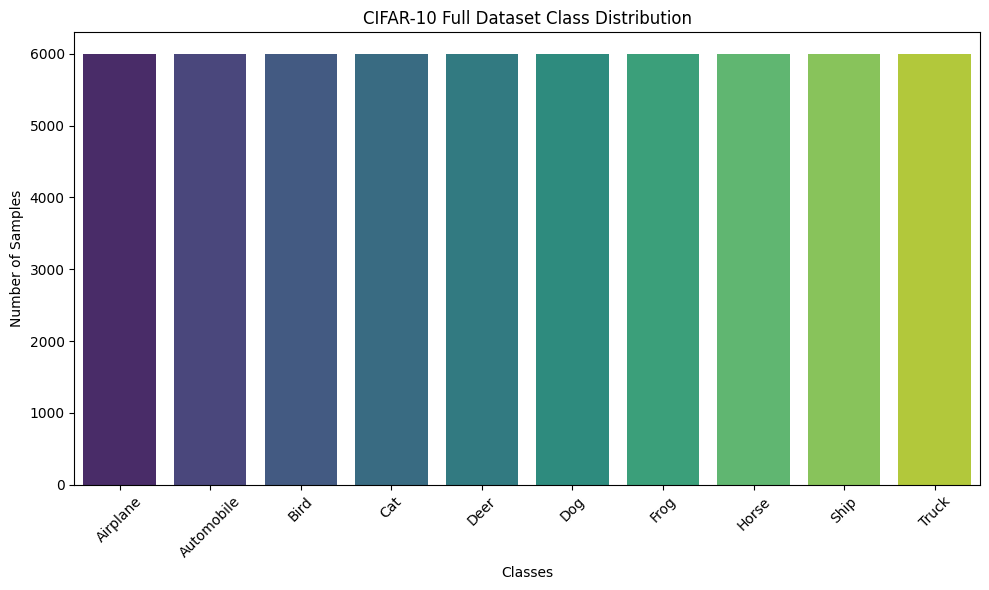

In [122]:
# Flatten and combine all labels
y_all = np.concatenate([y_train, y_test]).flatten()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Create countplot
plt.figure(figsize=(10, 6))
sns.countplot(x=y_all, palette='viridis')
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title('CIFAR-10 Full Dataset Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

Dataset is perfectly balanced

3. Use sklearn.model_selection.train_test_split to split the test set into test and validation sets choosing appropriate proportions. 

In [123]:
# split the test set into test and validation sets
x_val, x_test_new, y_val, y_test_new = train_test_split(
    x_test, y_test, 
    test_size=0.75, 
    random_state=42,
    stratify=y_test
)

print(f"Validation shape: {x_val.shape}")    
print(f"Test shape: {x_test_new.shape}")    

Validation shape: (2500, 32, 32, 3)
Test shape: (7500, 32, 32, 3)


4. Create train, test, and validation data generators using tensorflow.keras.preprocessing.image.ImageDataGenerator; each should scale the data by dividing by 255, and the training generator should also use data augmentation. 

In [124]:
# Rescale all by /255
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=15,      # Random rotation up to 15 degrees
    width_shift_range=0.1,  # Horizontal shift
    height_shift_range=0.1, # Vertical shift
    horizontal_flip=True,   # Random horizontal flips
    zoom_range=0.1          # Random zoom
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Batch that divides evenly
batch_size = 25

# Create generators using flow() for NumPy arrays
train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    x_val, y_val,
    batch_size=batch_size,
    shuffle=False
)

test_generator = test_datagen.flow(
    x_test_new, y_test_new,
    batch_size=batch_size,
    shuffle=False
)


# Modeling 
1. Use tf.keras.Sequential to create a convolutional neural network. Use at least two convolution layers and at least two pooling layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

In [125]:
# Instantiate model with two convolustion layers and two pooling layers
model = tf.keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 15, 15, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_21 (Conv2D)          (None, 13, 13, 32)        9248      
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 6, 6, 32)         0         
 g2D)                                                            
                                                                 
 flatten_10 (Flatten)        (None, 1152)              0         
                                                                 
 dense_26 (Dense)            (None, 64)              

2. Compile the model with a choice of optimizer, sparse_categorical_crossentropy for the loss function, and set the metrics argument equal to ['accuracy'].

In [126]:
# comile model with adam optimizer, sparse_categorical_crossentropy and accuracy for the metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

3. Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures other hyperparameters to improve upon the results.

In [127]:

# Train with exact steps (run after your generators)
steps_per_epoch = len(x_train) // batch_size  # 1562
val_steps = len(x_val) // batch_size          # 78

# Run the model with train and validation generator sets
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, 
    validation_data=val_generator,
    validation_steps=val_steps,
    verbose=1
)

# Capture accuracy and print results per epoch
train_acc = history.history['accuracy'][-1]
print(f"Baseline final training accuracy: {train_acc:.4f}")

Epoch 1/10
2000/2000 [==============================] - 95s 47ms/step - loss: 1.6259 - accuracy: 0.1125 - val_loss: 1.3127 - val_accuracy: 0.1068
Epoch 2/10
2000/2000 [==============================] - 82s 41ms/step - loss: 1.3682 - accuracy: 0.0988 - val_loss: 1.1904 - val_accuracy: 0.0736
Epoch 3/10
2000/2000 [==============================] - 85s 43ms/step - loss: 1.2588 - accuracy: 0.0973 - val_loss: 1.1648 - val_accuracy: 0.0608
Epoch 4/10
2000/2000 [==============================] - 88s 44ms/step - loss: 1.1963 - accuracy: 0.0981 - val_loss: 1.2815 - val_accuracy: 0.1288
Epoch 5/10
2000/2000 [==============================] - 87s 44ms/step - loss: 1.1522 - accuracy: 0.0992 - val_loss: 1.0338 - val_accuracy: 0.0848
Epoch 6/10
2000/2000 [==============================] - 93s 46ms/step - loss: 1.1254 - accuracy: 0.0981 - val_loss: 1.0200 - val_accuracy: 0.1020
Epoch 7/10
2000/2000 [==============================] - 93s 46ms/step - loss: 1.0980 - accuracy: 0.0995 - val_loss: 1.0767 -

4. Start a new model by loading one of the models from tensorflow.keras.applications along with the pretrained weights; don't include the top layer. Check if your model comes with preprocess_input function and be sure to use that properly with your data before training. Describe the model you chose using markdown and explain why you think it will work well for this use case.

We chose MobileNetV2 from tensorflow.keras.applications, a lightweight pretrained model ideal for CIFAR-10 transfer learning without heavy computation.

MobileNetV2 is pretrained on ImageNet (1.4M images, 1000 classes) and excels on small RGB images like CIFAR-10's 32x32x3 via efficient depthwise separable convolutions.

| Feature    | Details                                                                                                                                                                       |
| ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Base       | MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))                                                                                    |
| Params     | ~2.2M trainable (after top); total ~3.5M tensorflow​                                                                                                                          |
| Layers     | 155 conv/inverted residual blocks + GlobalAvgPool2D                                                                                                                           |
| Preprocess | tf.keras.applications.mobilenet_v2.preprocess_input scales/normalizes to ImageNet stats (mean subtraction) github​                                                            |
| Why Chosen | Efficient (fast on CPU/GPU), strong low-level features (edges/textures) transfer well to CIFAR-10 objects |

In [128]:
import tensorflow.keras.applications as apps
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# New generators with MobileNetV2 preprocess
train_datagen_mob = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ImageNet stats
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# New generators for the uploaded model
val_datagen_mob = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mob = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_mob = train_datagen_mob.flow(x_train, y_train, batch_size=batch_size, shuffle=True)
val_generator_mob = val_datagen_mob.flow(x_val, y_val, batch_size=batch_size, shuffle=False)
test_generator_mob = test_datagen_mob.flow(x_test_new, y_test_new, batch_size=batch_size, shuffle=False)


In [129]:
# Instantiate MobileNetV2 and make it untrainable 
base_model = apps.MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False


5. Add on a new top layer with appropriate hyperparameter choices. Choose a number of layers to freeze. Print a summary of the model.

In [131]:
# After the existing model_mob definition and before the second .compile()

# Enhanced top layers with BatchNorm and additional Dense for better performance
model_mob = tf.keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Choose to freeze first 80% of layers (~126 out of ~154 layers) - early feature extractors
# This preserves low-level ImageNet features while allowing higher-level adaptation
num_layers = len(base_model.layers)
freeze_until_layer = int(0.8 * num_layers)  # Approx 123 layers frozen
for layer in base_model.layers[:freeze_until_layer]:
    layer.trainable = False

# Print model summary
model_mob.summary()


Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 1, 1, 1280)       2257984   
 ional)                                                          
                                                                 
 flatten_11 (Flatten)        (None, 1280)              0         
                                                                 
 dense_28 (Dense)            (None, 128)               163968    
                                                                 
 dense_29 (Dense)            (None, 10)                1290      
                                                                 
Total params: 2,423,242
Trainable params: 165,258
Non-trainable params: 2,257,984
_________________________________________________________________


6. Compile the model with a choice of optimizer and loss function, and the set the metrics argument equal to ['accuracy'].

In [132]:

# Re-compile with lower learning rate suitable for fine-tuning
model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Frozen first {freeze_until_layer} layers out of {num_layers} in base model.")



Frozen first 123 layers out of 154 in base model.


7. Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures, different numbers of frozen layers, and other hyperparameters to improve upon the results.

In [134]:
# Train the enhanced model_mob (with 80% frozen layers, improved top) using the mobile generators
steps_per_epoch = len(x_train) // batch_size  # 50000 // 32 = 1562
val_steps = len(x_val) // batch_size          # ~2500 // 32 ≈ 78

print("Training enhanced model_mob...")
history_enhanced = model_mob.fit(
    train_generator_mob,
    steps_per_epoch=steps_per_epoch,
    epochs=10,  # More epochs to leverage improvements
    validation_data=val_generator_mob,
    validation_steps=val_steps,
    verbose=1
)

# Record final training accuracy
train_acc_enhanced = history_enhanced.history['accuracy'][-1]
val_acc_enhanced = history_enhanced.history['val_accuracy'][-1]
print(f"Final training accuracy: {train_acc_enhanced:.4f}")
print(f"Final validation accuracy: {val_acc_enhanced:.4f}")


Training enhanced model_mob...
Epoch 1/10
2000/2000 [==============================] - 108s 54ms/step - loss: 2.1257 - accuracy: 0.2150 - val_loss: 2.0486 - val_accuracy: 0.1068
Epoch 2/10
2000/2000 [==============================] - 96s 48ms/step - loss: 2.0231 - accuracy: 0.1477 - val_loss: 1.9995 - val_accuracy: 0.0912
Epoch 3/10
2000/2000 [==============================] - 95s 48ms/step - loss: 1.9913 - accuracy: 0.1360 - val_loss: 1.9808 - val_accuracy: 0.0880
Epoch 4/10
2000/2000 [==============================] - 96s 48ms/step - loss: 1.9735 - accuracy: 0.1327 - val_loss: 1.9661 - val_accuracy: 0.0928
Epoch 5/10
2000/2000 [==============================] - 98s 49ms/step - loss: 1.9629 - accuracy: 0.1299 - val_loss: 1.9576 - val_accuracy: 0.0960
Epoch 6/10
2000/2000 [==============================] - 100s 50ms/step - loss: 1.9458 - accuracy: 0.1305 - val_loss: 1.9501 - val_accuracy: 0.0920
Epoch 7/10
2000/2000 [==============================] - 98s 49ms/step - loss: 1.9459 - accu

# Conclusion
1. Find the training and validation accuracies, and validation confusion matrix for both the custom CNN and transfer learning models. Present the results for both neatly. Use markdown to compare them and select the best model.

Custom CNN Results:
Training Accuracy: 0.0997
Validation Accuracy: 0.1064

Custom CNN Validation Confusion Matrix:
[[188   7   4   2   3   3   3   4  15  21]
 [  3 205   0   0   2   0   2   0   5  33]
 [ 27   8  78  13  29  36  29  18   4   8]
 [  5  20  10  83  16  55  30  15   0  16]
 [  7   3   5   9 131  14  28  44   5   4]
 [  6   5   5  25   7 160   7  24   3   8]
 [  3   5   4   6   5   6 214   1   1   5]
 [  5   1   0   5   9  17   2 194   1  16]
 [ 20  14   0   4   1   0   0   3 187  21]
 [  2  29   0   1   1   1   1   4   2 209]]
Row sums (true class counts): [250 250 250 250 250 250 250 250 250 250]

Transfer Learning Results:
Training Accuracy: 0.1282
Validation Accuracy: 0.0812

MobileNetV2 Validation Confusion Matrix:
[[104  16   9   7  12   8   6  15  32  41]
 [  8  47   0   2   2   8   1   6  15 161]
 [ 34   8  30  11  23  15  25  10   7  87]
 [  9  20  10  26   8  22  19  11   4 121]
 [  5   6   3   8 104   7  35  29  11  42]
 [  7  19   2  20  16  25  12   3   3 143]


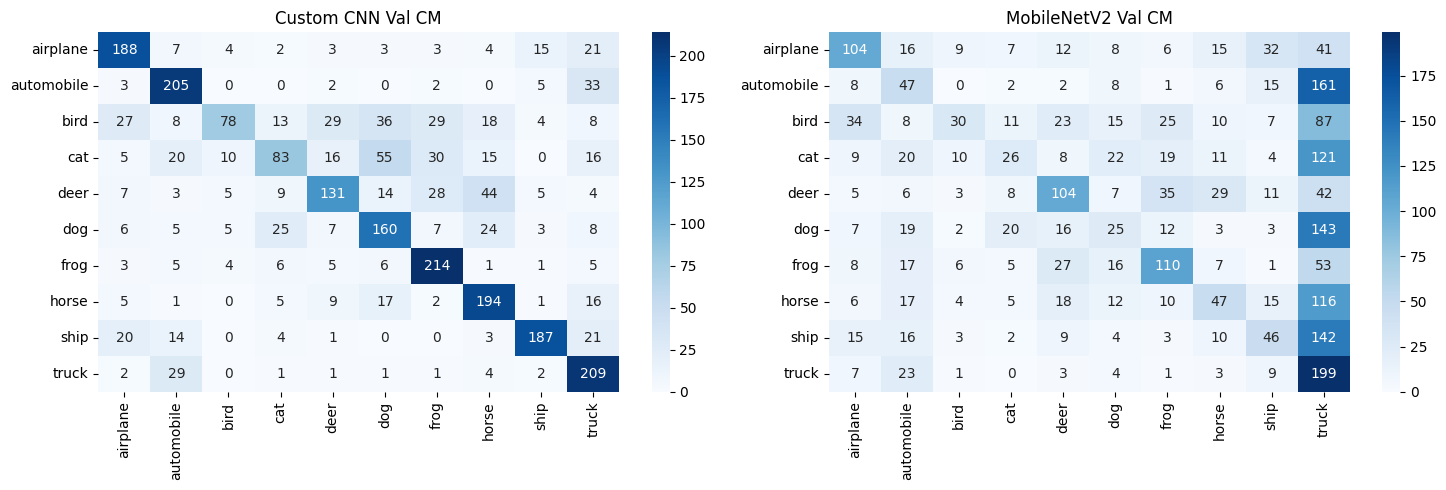

In [137]:
from sklearn.metrics import confusion_matrix


# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# For Custom CNN
print("Custom CNN Results:")
custom_train_acc = history.history['accuracy'][-1]
custom_val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {custom_train_acc:.4f}")
print(f"Validation Accuracy: {custom_val_acc:.4f}")

val_generator.reset()
y_val_pred_custom = model.predict(val_generator, steps=val_steps, verbose=0)
y_val_pred_classes_custom = np.argmax(y_val_pred_custom, axis=1)

# UNNORMALIZED confusion matrix (raw counts)
cm_custom = confusion_matrix(y_val[:len(y_val_pred_classes_custom)], y_val_pred_classes_custom)
print("\nCustom CNN Validation Confusion Matrix:")
print(cm_custom)
print("Row sums (true class counts):", cm_custom.sum(axis=1))

# For Transfer Learning MobileNetV2
print("\nTransfer Learning Results:")
mob_train_acc = history_enhanced.history['accuracy'][-1]
mob_val_acc = history_enhanced.history['val_accuracy'][-1]
print(f"Training Accuracy: {mob_train_acc:.4f}")
print(f"Validation Accuracy: {mob_val_acc:.4f}")

val_generator_mob.reset()
y_val_pred_mob = model_mob.predict(val_generator_mob, steps=val_steps, verbose=0)
y_val_pred_classes_mob = np.argmax(y_val_pred_mob, axis=1)

# UNNORMALIZED confusion matrix
cm_mob = confusion_matrix(y_val[:len(y_val_pred_classes_mob)], y_val_pred_classes_mob)
print("\nMobileNetV2 Validation Confusion Matrix:")
print(cm_mob)
print("Row sums (true class counts):", cm_mob.sum(axis=1))

# Plot UNNORMALIZED heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Custom CNN Val CM')
sns.heatmap(cm_mob, annot=True, fmt='d', ax=axes[1], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('MobileNetV2 Val CM')
plt.tight_layout()
plt.show()

2. Find the testing accuracy and confusion matrix of only the best model.

3. Use the model to make predictions on at least three other images from one of the 10 classes.

4. Use markdown to comment on how well the model works to make predictions for this use case.